In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 10,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

# Numerical Integration, with constant and exponential SFRs

Numerical integrations:

In [2]:
t_array = np.linspace(0,14,int(1e3))
model = evo.Galaxy(t_array)
m_g_array_const = np.ones(len(t_array))
Z_oxygen_const = model.compute_z_O(m_g_array_const)
Z_Iron_const = model.compute_z_Fe(m_g_array_const)

tau_sfh = model.tau_sfh_arr[0]
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
Z_oxygen_exp = model.compute_z_O(m_g_array_exp)
M_O_exp = model.integrate_m_O(m_g_array_exp)
Z_Iron_exp = model.compute_z_Fe(m_g_array_exp)

Analytical solutions to compare:

In [3]:
Z_O_eq_const_sfr = model.analytic_eq_O("constant")
Z_O_const_sfr_ana = model.analytic_solutions_O("constant")

Z_O_eq_exp_sfr = model.analytic_eq_O("exponential")
Z_O_exp_sfr_ana = model.analytic_solutions_O("exponential")

In [4]:
Z_Fe_eq_const_sfr = model.analytic_eq_Fe("constant")
Z_Fe_const_sfr_ana = model.analytic_solutions_Fe("constant", 'sum')

Z_Fe_eq_exp_sfr = model.analytic_eq_Fe("exponential")
Z_Fe_exp_sfr_ana = model.analytic_solutions_Fe("exponential", 'sum')

# Oxygen abundance 

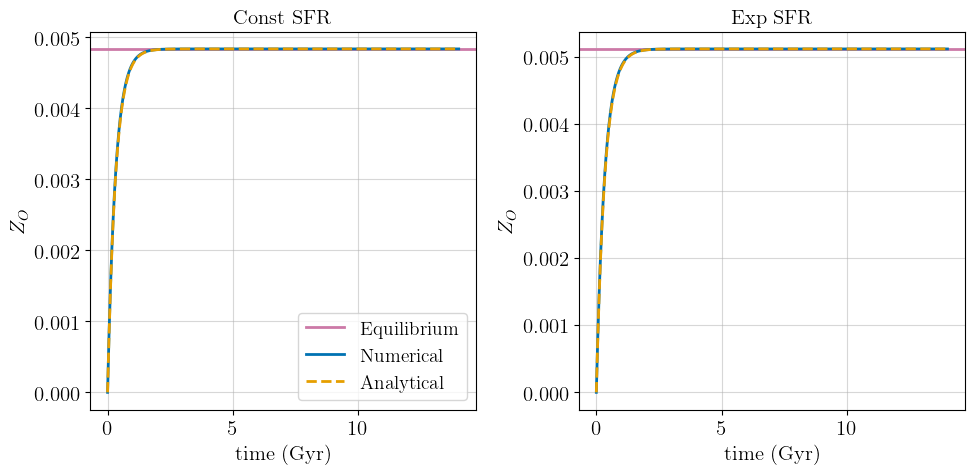

In [5]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.axhline(Z_O_eq_const_sfr, color = colors[4], label = 'Equilibrium', lw = 2)
plt.plot(t_array, Z_oxygen_const, color = colors[0], lw = 2, label = 'Numerical')
plt.plot(t_array, Z_O_const_sfr_ana, color = colors[1], alpha = 1, label = 'Analytical', lw = 2, linestyle = '--')

plt.grid('True', alpha = 0.5)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{O}$')
plt.title("Const SFR")
plt.legend(fontsize=14)
plt.tight_layout()



plt.subplot(1, 2, 2)
plt.axhline(Z_O_eq_exp_sfr, lw = 2, color = colors[4])
plt.plot(t_array, Z_oxygen_exp, color = colors[0], lw = 2)
plt.plot(t_array, Z_O_exp_sfr_ana, color = colors[1], lw = 2, linestyle = '--')

plt.grid('True', alpha = 0.5)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{O}$')
plt.title("Exp SFR")
plt.tight_layout()

# Iron abundance

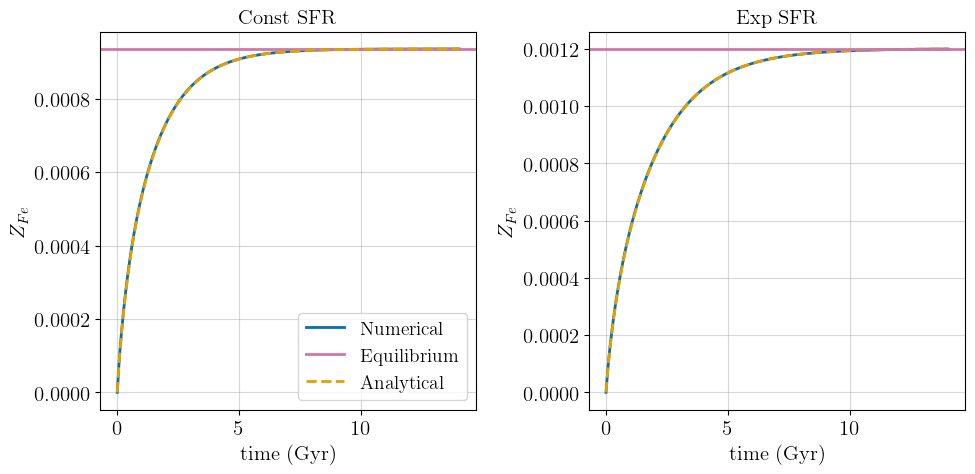

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(t_array, Z_Iron_const, color = colors[0], alpha = 1, lw = 2, label = 'Numerical')
plt.axhline(Z_Fe_eq_const_sfr, color = colors[4], label = 'Equilibrium', lw = 2)
plt.plot(t_array, Z_Fe_const_sfr_ana, color = colors[1], alpha = 1, label = 'Analytical', lw = 2, linestyle = '--')

plt.grid('True', alpha = 0.5)
plt.legend(fontsize = 14)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Const SFR")
plt.tight_layout()



plt.subplot(1, 2, 2)
plt.plot(t_array, Z_Iron_exp, color = colors[0], lw = 2)
plt.plot(t_array, Z_Fe_exp_sfr_ana, color = colors[1], lw = 2, linestyle = '--')
plt.axhline(Z_Fe_eq_exp_sfr[0], color = colors[4], lw = 2)

plt.grid('True', alpha = 0.5)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Exp SFR")
plt.tight_layout()

In [7]:
etas = [2.5, 5, 1, 2.5]
tau_stars = [1, 1, 1, 3]

oxys_list_const = []
irons_list_const = []

oxys_list_exp = []
irons_list_exp = []

#Const SFR
for i in range(len(etas)):
    model_i = evo.Galaxy(t_array, eta=etas[i], tau_star=tau_stars[i])
    oxys_list_const.append(model_i.compute_z_O(m_g_array_const))
    irons_list_const.append(model_i.compute_z_Fe(m_g_array_const))

In [8]:
#Exp SFR
for i in range(len(etas)):
    model_i = evo.Galaxy(t_array, eta=etas[i], tau_star=tau_stars[i])
    oxys_list_exp.append(model_i.compute_z_O(m_g_array_exp))
    irons_list_exp.append(model_i.compute_z_Fe(m_g_array_exp))

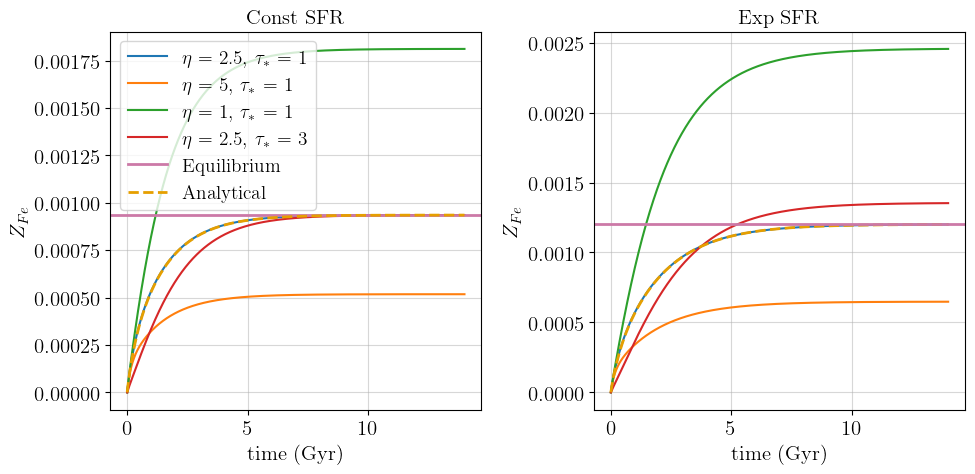

In [9]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
for i in range(len(etas)):
    plt.plot(t_array, irons_list_const[i], label = r'$\eta$ = ' + f"{etas[i]}" + r', $\tau_{*}$ = ' + f"{tau_stars[i]}")


plt.axhline(Z_Fe_eq_const_sfr, color = colors[4], label = 'Equilibrium', lw = 2)
plt.plot(t_array, Z_Fe_const_sfr_ana, color = colors[1], alpha = 1, label = 'Analytical', lw = 2, linestyle = '--')

plt.grid('True', alpha = 0.5)
plt.legend(fontsize = 14)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Const SFR")
plt.tight_layout()



plt.subplot(1, 2, 2)
for i in range(len(etas)):
    plt.plot(t_array, irons_list_exp[i], label = r'$\eta$ = ' + f"{etas[i]}" + r', $\tau_{*}$ = ' + f"{tau_stars[i]}")

plt.plot(t_array, Z_Fe_exp_sfr_ana, color = colors[1], lw = 2, linestyle = '--')
plt.axhline(Z_Fe_eq_exp_sfr[0], color = colors[4], lw = 2)

plt.grid('True', alpha = 0.5)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Exp SFR")
plt.tight_layout()

In [17]:
t_array = np.linspace(0,14,10000)
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)

In [18]:
model_no_ccsn = evo.Galaxy(t_array, m_Fe_cc=0)
iron_numeric_cc = model_no_ccsn.compute_z_Fe(m_g_array_exp)
iron_anal_cc_cc, iron_anal_cc_ia, iron_anal_cc_sum = model_no_ccsn.analytic_solutions_Fe(SFR_function="exponential", Z_type='all')
iron_anal_eq_sum, iron_anal_eq_cc, iron_anal_eq_ia = model_no_ccsn.analytic_eq_Fe(SFR_function="exponential")

model_no_ia = evo.Galaxy(t_array, m_Fe_Ia=0)
iron_numeric_ia = model_no_ia.compute_z_Fe(m_g_array_exp)
iron_anal_ia = model_no_ia.analytic_solutions_Fe(SFR_function="exponential", Z_type='sum')

In [19]:
iron_anal_eq_cc

np.float64(0.0)

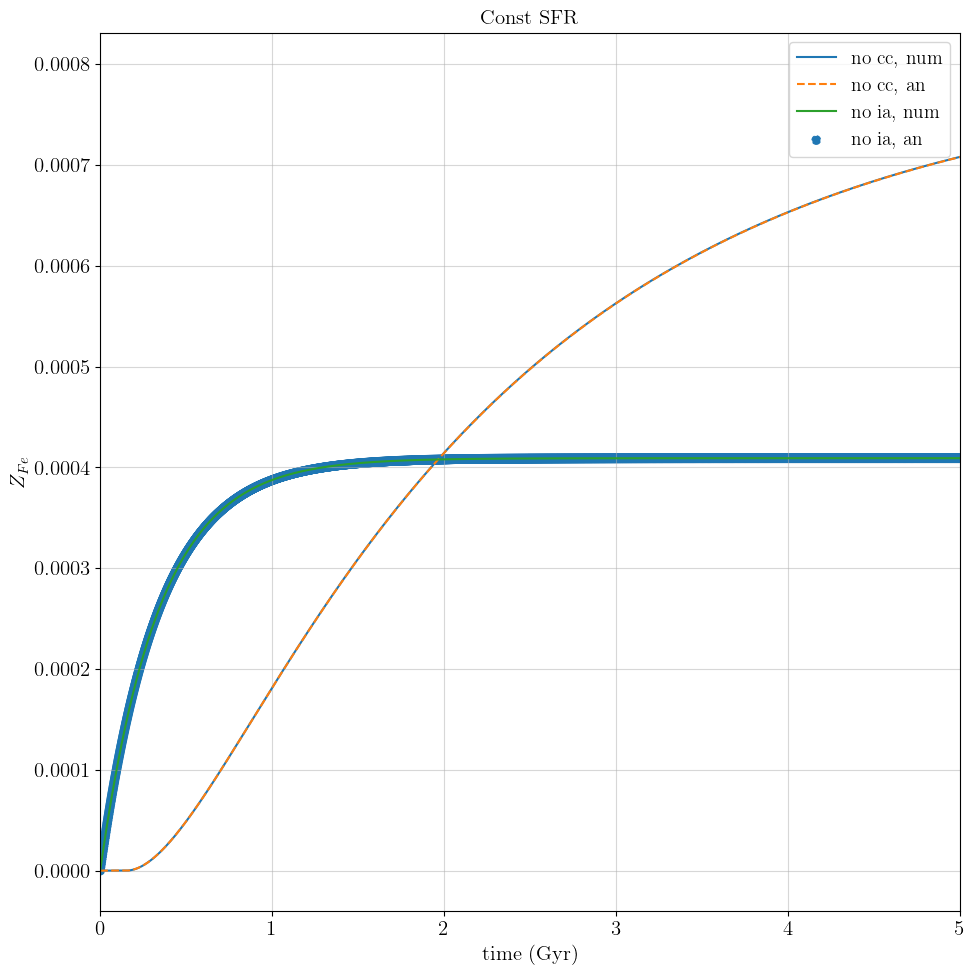

In [20]:
plt.figure(figsize=(10,10))

plt.plot(t_array, iron_numeric_cc, label = 'no cc, num')
plt.plot(t_array, iron_anal_cc_sum, linestyle = '--', label = 'no cc, an')

plt.plot(t_array, iron_numeric_ia, label = 'no ia, num')
plt.scatter(t_array, iron_anal_ia, linestyle = '--', label = 'no ia, an')


plt.xlim(0,5)
plt.grid('True', alpha = 0.5)
plt.legend(fontsize = 14)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Const SFR")
plt.tight_layout()

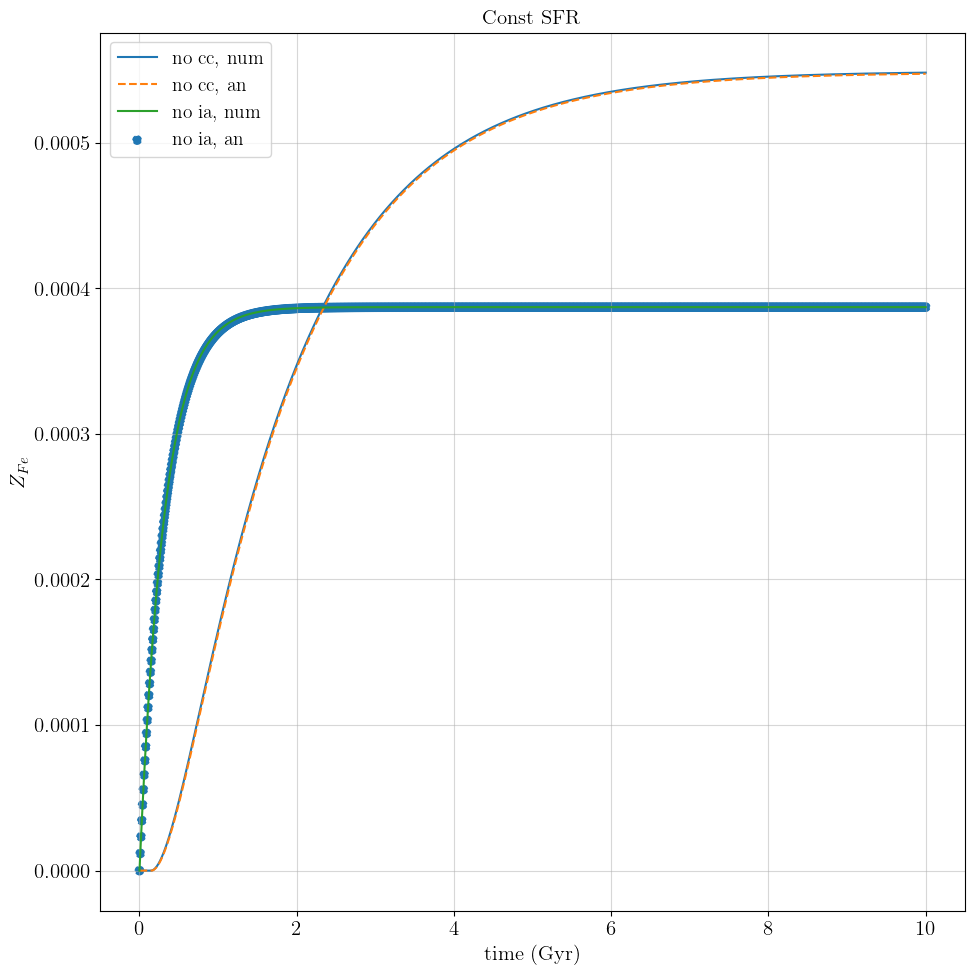

In [26]:
t_array = np.linspace(0,10,1000)
m_g_array_const = 1 * np.ones(len(t_array))
model_no_ccsn = evo.Galaxy(t_array, m_Fe_cc=0)

iron_numeric_cc = model_no_ccsn.compute_z_Fe(m_g_array_const)
iron_anal_cc_cc, iron_anal_cc_ia, iron_anal_cc_sum = model_no_ccsn.analytic_solutions_Fe(SFR_function="constant", Z_type='all')

model_no_ia = evo.Galaxy(t_array, m_Fe_Ia=0)
iron_numeric_ia = model_no_ia.compute_z_Fe(m_g_array_const)
iron_anal_ia = model_no_ia.analytic_solutions_Fe(SFR_function="constant", Z_type='sum')


plt.figure(figsize=(10,10))

plt.plot(t_array, iron_numeric_cc, label = 'no cc, num')
plt.plot(t_array, iron_anal_cc_sum, linestyle = '--', label = 'no cc, an')

plt.plot(t_array, iron_numeric_ia, label = 'no ia, num')
plt.scatter(t_array, iron_anal_ia, linestyle = '--', label = 'no ia, an')


#0plt.xlim(0,2)
plt.grid('True', alpha = 0.5)
plt.legend(fontsize = 14)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Const SFR")
plt.tight_layout()

In [22]:
Z_Fe_eq_exp, Z_Fe_eq_cc_exp, Z_Fe_eq_Ia_exp = 2, 0, 1
tau_dep_sfh = 0.341
tau_dep_Ia = 0.412
tau_Ia_sfh = 2
td = 1
delta_t = t_array - td
Z_Fe_cc_analytic = Z_Fe_eq_cc_exp * (1 - np.exp(-t_array/tau_dep_sfh))
Z_Fe_Ia_analytic = Z_Fe_eq_Ia_exp * (1 - np.exp(-delta_t/tau_dep_sfh) - (tau_dep_Ia/tau_dep_sfh) * (np.exp(-t_array/tau_Ia_sfh) - np.exp(-delta_t/tau_dep_sfh)))
Z_Fe_analytic = Z_Fe_cc_analytic + Z_Fe_Ia_analytic